In [2]:
import pandas as pd
import numpy as np
import matplotlib. pyplot as plt
from scipy.stats import norm

%load_ext autoreload
%autoreload 2

In [15]:
# Define the file path
file_path = "data/case_study_data.xlsx"

# Load the Excel file
xls = pd.ExcelFile(file_path)

# Read the "ZC yields" sheet (case insensitive)
zc_yields_df = pd.read_excel(xls, sheet_name="ZC yields",index_col=0)

In [13]:
zc_yields_df

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
Zero-coupon yield curves,,,,,,,,,,,,,,,,,,,,,
Maturity (years),0.000000,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,...,21.000000,22.000000,23.000000,24.000000,25.000000,26.000000,27.000000,28.000000,29.000000,30.000000
Effective date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-10-31 00:00:00,0.001525,0.001525,0.005385,0.009872,0.013707,0.016728,0.019069,0.020903,0.022370,0.023573,...,0.030328,0.030618,0.030887,0.031137,0.031370,0.031587,0.031791,0.031981,0.032160,0.032327
2014-11-03 00:00:00,0.001631,0.001631,0.005533,0.010066,0.013901,0.016893,0.019199,0.020998,0.022437,0.023617,...,0.030274,0.030560,0.030825,0.031071,0.031299,0.031513,0.031712,0.031899,0.032074,0.032238
2014-11-04 00:00:00,0.001439,0.001439,0.005512,0.010062,0.013873,0.016836,0.019115,0.020892,0.022312,0.023476,...,0.030027,0.030307,0.030566,0.030807,0.031032,0.031241,0.031436,0.031619,0.031790,0.031951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-28 00:00:00,0.042701,0.042701,0.040979,0.040501,0.040558,0.040855,0.041258,0.041703,0.042157,0.042604,...,0.046125,0.046271,0.046398,0.046509,0.046604,0.046683,0.046749,0.046801,0.046841,0.046870
2024-10-29 00:00:00,0.042583,0.042583,0.040861,0.040406,0.040491,0.040813,0.041238,0.041702,0.042171,0.042630,...,0.046145,0.046283,0.046402,0.046503,0.046588,0.046658,0.046713,0.046755,0.046785,0.046803
2024-10-30 00:00:00,0.042760,0.042760,0.041321,0.040869,0.040888,0.041134,0.041487,0.041885,0.042296,0.042701,...,0.045830,0.045949,0.046051,0.046138,0.046209,0.046267,0.046311,0.046343,0.046364,0.046374


In [16]:
# Drop the first row (column names) and the second row (which contains NaN)
zc_yields_df = zc_yields_df.iloc[2:]
zc_yields_df

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
Zero-coupon yield curves,,,,,,,,,,,,,,,,,,,,,
2014-10-31,0.001525,0.001525,0.005385,0.009872,0.013707,0.016728,0.019069,0.020903,0.022370,0.023573,...,0.030328,0.030618,0.030887,0.031137,0.031370,0.031587,0.031791,0.031981,0.032160,0.032327
2014-11-03,0.001631,0.001631,0.005533,0.010066,0.013901,0.016893,0.019199,0.020998,0.022437,0.023617,...,0.030274,0.030560,0.030825,0.031071,0.031299,0.031513,0.031712,0.031899,0.032074,0.032238
2014-11-04,0.001439,0.001439,0.005512,0.010062,0.013873,0.016836,0.019115,0.020892,0.022312,0.023476,...,0.030027,0.030307,0.030566,0.030807,0.031032,0.031241,0.031436,0.031619,0.031790,0.031951
2014-11-05,0.001556,0.001556,0.005611,0.010135,0.013922,0.016873,0.019152,0.020938,0.022374,0.023555,...,0.030160,0.030433,0.030685,0.030918,0.031135,0.031335,0.031523,0.031697,0.031860,0.032013
2014-11-06,0.001682,0.001682,0.005814,0.010413,0.014241,0.017211,0.019498,0.021290,0.022729,0.023916,...,0.030549,0.030822,0.031074,0.031307,0.031523,0.031723,0.031910,0.032084,0.032246,0.032398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-28,0.042701,0.042701,0.040979,0.040501,0.040558,0.040855,0.041258,0.041703,0.042157,0.042604,...,0.046125,0.046271,0.046398,0.046509,0.046604,0.046683,0.046749,0.046801,0.046841,0.046870
2024-10-29,0.042583,0.042583,0.040861,0.040406,0.040491,0.040813,0.041238,0.041702,0.042171,0.042630,...,0.046145,0.046283,0.046402,0.046503,0.046588,0.046658,0.046713,0.046755,0.046785,0.046803
2024-10-30,0.042760,0.042760,0.041321,0.040869,0.040888,0.041134,0.041487,0.041885,0.042296,0.042701,...,0.045830,0.045949,0.046051,0.046138,0.046209,0.046267,0.046311,0.046343,0.046364,0.046374


,Zero-coupon yield curves,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,2014-10-31 00:00:00,0.001525,0.001525,0.005385,0.009872,0.013707,0.016728,0.019069,0.020903,0.022370,...,0.030328,0.030618,0.030887,0.031137,0.031370,0.031587,0.031791,0.031981,0.032160,0.032327
1,2014-11-03 00:00:00,0.001631,0.001631,0.005533,0.010066,0.013901,0.016893,0.019199,0.020998,0.022437,...,0.030274,0.030560,0.030825,0.031071,0.031299,0.031513,0.031712,0.031899,0.032074,0.032238
2,2014-11-04 00:00:00,0.001439,0.001439,0.005512,0.010062,0.013873,0.016836,0.019115,0.020892,0.022312,...,0.030027,0.030307,0.030566,0.030807,0.031032,0.031241,0.031436,0.031619,0.031790,0.031951
3,2014-11-05 00:00:00,0.001556,0.001556,0.005611,0.010135,0.013922,0.016873,0.019152,0.020938,0.022374,...,0.030160,0.030433,0.030685,0.030918,0.031135,0.031335,0.031523,0.031697,0.031860,0.032013
4,2014-11-06 00:00:00,0.001682,0.001682,0.005814,0.010413,0.014241,0.017211,0.019498,0.021290,0.022729,...,0.030549,0.030822,0.031074,0.031307,0.031523,0.031723,0.031910,0.032084,0.032246,0.032398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2513,2024-10-28 00:00:00,0.042701,0.042701,0.040979,0.040501,0.040558,0.040855,0.041258,0.041703,0.042157,...,0.046125,0.046271,0.046398,0.046509,0.046604,0.046683,0.046749,0.046801,0.046841,0.046870
2514,2024-10-29 00:00:00,0.042583,0.042583,0.040861,0.040406,0.040491,0.040813,0.041238,0.041702,0.042171,...,0.046145,0.046283,0.046402,0.046503,0.046588,0.046658,0.046713,0.046755,0.046785,0.046803
2515,2024-10-30 00:00:00,0.042760,0.042760,0.041321,0.040869,0.040888,0.041134,0.041487,0.041885,0.042296,...,0.045830,0.045949,0.046051,0.046138,0.046209,0.046267,0.046311,0.046343,0.046364,0.046374
2516,2024-10-31 00:00:00,0.042704,0.042704,0.041250,0.040893,0.040968,0.041225,0.041560,0.041922,0.042289,...,0.045508,0.045631,0.045739,0.045834,0.045917,0.045988,0.046047,0.046097,0.046136,0.046166


In [22]:

# Rename remaining columns to match the maturity values (0-30 years)
maturity_columns = list(range(0, 31))
zc_yields_df.columns = maturity_columns[:len(zc_yields_df.columns)]
zc_yields_df.index.name = "Date"


In [23]:
zc_yields_df

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
Date,,,,,,,,,,,,,,,,,,,,,
2014-10-31,0.001525,0.001525,0.005385,0.009872,0.013707,0.016728,0.019069,0.020903,0.022370,0.023573,...,0.030328,0.030618,0.030887,0.031137,0.031370,0.031587,0.031791,0.031981,0.032160,0.032327
2014-11-03,0.001631,0.001631,0.005533,0.010066,0.013901,0.016893,0.019199,0.020998,0.022437,0.023617,...,0.030274,0.030560,0.030825,0.031071,0.031299,0.031513,0.031712,0.031899,0.032074,0.032238
2014-11-04,0.001439,0.001439,0.005512,0.010062,0.013873,0.016836,0.019115,0.020892,0.022312,0.023476,...,0.030027,0.030307,0.030566,0.030807,0.031032,0.031241,0.031436,0.031619,0.031790,0.031951
2014-11-05,0.001556,0.001556,0.005611,0.010135,0.013922,0.016873,0.019152,0.020938,0.022374,0.023555,...,0.030160,0.030433,0.030685,0.030918,0.031135,0.031335,0.031523,0.031697,0.031860,0.032013
2014-11-06,0.001682,0.001682,0.005814,0.010413,0.014241,0.017211,0.019498,0.021290,0.022729,0.023916,...,0.030549,0.030822,0.031074,0.031307,0.031523,0.031723,0.031910,0.032084,0.032246,0.032398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-28,0.042701,0.042701,0.040979,0.040501,0.040558,0.040855,0.041258,0.041703,0.042157,0.042604,...,0.046125,0.046271,0.046398,0.046509,0.046604,0.046683,0.046749,0.046801,0.046841,0.046870
2024-10-29,0.042583,0.042583,0.040861,0.040406,0.040491,0.040813,0.041238,0.041702,0.042171,0.042630,...,0.046145,0.046283,0.046402,0.046503,0.046588,0.046658,0.046713,0.046755,0.046785,0.046803
2024-10-30,0.042760,0.042760,0.041321,0.040869,0.040888,0.041134,0.041487,0.041885,0.042296,0.042701,...,0.045830,0.045949,0.046051,0.046138,0.046209,0.046267,0.046311,0.046343,0.046364,0.046374


In [ ]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline

# zc_yields_df: rows = dates, columns = maturities (in years)
dates = zc_yields_df.index
maturities = zc_yields_df.columns.astype(float)  

initial_date = dates[0]
discount_factors = []

for current_date in dates:
    # 1. Day-count fraction from initial_date to current_date
    delta_days = (current_date - initial_date).days  # day-count
    delta_t = delta_days / 365.0  # if using Actual/365

    # 2. Effective maturity for the original 10-year instrument
    T_eff = 10 - delta_t
    if T_eff <= 0:
        # Once T_eff <= 0, the bond is effectively matured
        discount_factors.append(1.0)
        continue

    # 3. Fit cubic spline for this date
    yields_today = zc_yields_df.loc[current_date, :].values  # yields for each maturity
    spline = CubicSpline(maturities, yields_today)

    # 4. Interpolate yield for T_eff
    yield_T = spline(T_eff)  # annualized zero-coupon yield

    # 5. Compute discount factor (continuous compounding)
    DF = np.exp(-yield_T * T_eff)
    discount_factors.append(DF)

# Convert discount_factors into a Series for convenience
df_result = pd.Series(discount_factors, index=dates, name="DiscountFactor_10yr")


In [25]:
df_result

Date
2014-10-31    0.782063
2014-11-03    0.782077
2014-11-04    0.783352
2014-11-05    0.782667
2014-11-06    0.779901
                ...   
2024-10-28    1.000000
2024-10-29    1.000000
2024-10-30    1.000000
2024-10-31    1.000000
2024-11-01    1.000000
Name: DiscountFactor_10yr, Length: 2518, dtype: float64

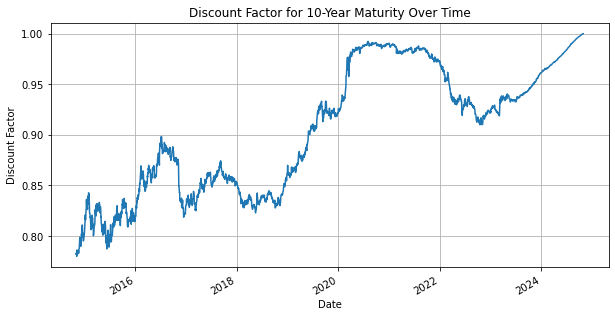

In [26]:
import matplotlib.pyplot as plt

# Plot the discount factor series
plt.figure(figsize=(10, 5))
df_result.plot()
plt.title("Discount Factor for 10-Year Maturity Over Time")
plt.xlabel("Date")
plt.ylabel("Discount Factor")
plt.grid(True)
plt.show()